In [2]:
import os
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# 1. Fix the HuggingFace Tokenizers Warning
# This must be set before you use the tokenizer
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 2. Suppress Sklearn "UndefinedMetricWarning"
# These appear because your Adversarial dataset has NO "Human" (Class 0) samples,
# so the math for Class 0 precision/recall tries to divide by zero.
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# 3. Suppress the Scalar "feature names" UserWarning
warnings.filterwarnings("ignore", category=UserWarning)

print("Warnings suppressed. You can now run the evaluation code cleanly.")

Warnings suppressed. You can now run the evaluation code cleanly.


In [3]:
# --- Cell 1: Imports & Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Crucial for saving/loading models (Resume feature)
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# Configuration
INPUT_CSV = '/kaggle/input/features-matrix/features_matrix.csv' # Ensure this matches your Phase 1 output filename
MODEL_DIR = './models' # Directory to save checkpoints

# Create directory if it doesn't exist
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

print("Setup Complete. Checkpoints will be saved to:", MODEL_DIR)

Setup Complete. Checkpoints will be saved to: ./models


In [4]:
feature_cols = ['perplexity', 'burstiness', 'flesch_score', 'grade_level', 'word_count', 'naturalness_score']
target_col = 'generated'

# --- 1. Load Data ---
print("Loading Datasets...")
# Standard Dataset (Human vs Standard AI)
feature_df = pd.read_csv('/kaggle/input/features-matrix/features_matrix.csv')

# Adversarial Datasets (Zero-Shot & Few-Shot)
zs_adv_feat_df = pd.read_csv('/kaggle/input/adv-features/adversarial_feature_matrix.csv')
fs_adv_feat_df = pd.read_csv('/kaggle/input/adv-features/few_shot_adversarial_feature_matrix.csv')

# --- 2. Initial Cleanup ---
# Drop rows where target is missing in the main training data
feature_df = feature_df.dropna(subset=[target_col])

# --- 3. Split Standard Data ---
# We split FIRST so we can fit our preprocessors only on X_train
X = feature_df[feature_cols]
y = feature_df[target_col]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Prepare Adversarial X and y
X_zs_raw = zs_adv_feat_df[feature_cols]
y_zs = np.ones(len(X_zs_raw)) # Adversarial data is always AI (Class 1)

X_fs_raw = fs_adv_feat_df[feature_cols]
y_fs = np.ones(len(X_fs_raw)) # Adversarial data is always AI (Class 1)

# --- 4. Impute Missing Values ---
print("Imputing NaNs...")
imputer = SimpleImputer(strategy='mean')

# FIT on Training Data ONLY
imputer.fit(X_train_raw)

# Transform all datasets
X_train_imputed = imputer.transform(X_train_raw)
X_test_imputed = imputer.transform(X_test_raw)
X_zs_imputed = imputer.transform(X_zs_raw)
X_fs_imputed = imputer.transform(X_fs_raw)

# --- 5. Scale Features ---
print("Scaling Features...")
scaler = StandardScaler()

# FIT on Training Data ONLY
scaler.fit(X_train_imputed)

# Transform all datasets
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
X_zs_scaled = scaler.transform(X_zs_imputed)
X_fs_scaled = scaler.transform(X_fs_imputed)

# --- 6. Save Processed Data & Scaler ---
# Save the Scaler for future use
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler.joblib'))
joblib.dump(imputer, os.path.join(MODEL_DIR, 'imputer.joblib'))

# Save the processed numpy arrays for easy loading in your experiment notebooks
np.save('X_train_features.npy', X_train_scaled)
np.save('y_train_features.npy', y_train.to_numpy())

np.save('X_test_features.npy', X_test_scaled)
np.save('y_test_features.npy', y_test.to_numpy())

np.save('X_zs_adv_features.npy', X_zs_scaled)
np.save('y_zs_adv_features.npy', y_zs)

np.save('X_fs_adv_features.npy', X_fs_scaled)
np.save('y_fs_adv_features.npy', y_fs)

# Also save the Human-Only Training set for Track 3 (One-Class Learning)
# We filter the already scaled X_train using the y_train indices
X_train_human_scaled = X_train_scaled[y_train == 0]
np.save('X_train_human_features.npy', X_train_human_scaled)

print("\n=== Preprocessing Complete ===")
print(f"Training Set: {X_train_scaled.shape}")
print(f"Test Set:     {X_test_scaled.shape}")
print(f"Human-Only (for OCL): {X_train_human_scaled.shape}")
print(f"Zero-Shot Adv Set:    {X_zs_scaled.shape}")
print(f"Few-Shot Adv Set:     {X_fs_scaled.shape}")
print("All files saved as .npy")

Loading Datasets...
Imputing NaNs...
Scaling Features...

=== Preprocessing Complete ===
Training Set: (232710, 6)
Test Set:     (58178, 6)
Human-Only (for OCL): (91190, 6)
Zero-Shot Adv Set:    (500, 6)
Few-Shot Adv Set:     (500, 6)
All files saved as .npy


In [7]:
# --- Cell 3: Smart Training Function & Metrics (Corrected) ---
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, confusion_matrix, classification_report

def train_or_load_model(name, model_class, X_tr, y_tr, kwargs={}):
    """
    Checks if model exists. If yes, loads it. If no, trains and saves it.
    """
    file_path = os.path.join(MODEL_DIR, f"{name}.joblib")
    
    if os.path.exists(file_path):
        print(f"✅ Found saved model for '{name}'. Loading from disk...")
        model = joblib.load(file_path)
    else:
        print(f"⏳ Training '{name}'... (This may take time)")
        model = model_class(**kwargs)
        model.fit(X_tr, y_tr)
        joblib.dump(model, file_path)
        print(f"💾 Saved '{name}' to disk.")
        
    return model

def evaluate_performance(name, model, X_te, y_te):
    """
    Generates metrics. Handles the 'Only one class' error for AUROC.
    """
    print(f"\n--- Results for {name} ---")
    y_pred = model.predict(X_te)
    
    # Check if model supports probability prediction (for AUROC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te) # For LinearSVC
        
    # Metrics
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    recall = recall_score(y_te, y_pred, zero_division=0)
    
    # --- FIX: Safe AUROC Calculation ---
    # AUROC is undefined if y_te has only 1 class (e.g. all 1s in adversarial set)
    if len(np.unique(y_te)) > 1:
        auc = roc_auc_score(y_te, y_prob)
        print(f"AUROC Score: {auc:.4f}")
    else:
        auc = 0.0 # Default value for single-class sets
        print("AUROC Score: N/A (Single class in test set)")
    # -----------------------------------
    
    print(classification_report(y_te, y_pred, zero_division=0))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return {
        "Model": name, 
        "Accuracy": acc, 
        "F1-Score": f1, 
        "Recall": recall, 
        "AUROC": auc
    }

# Reset the results list
benchmark_results = []

✅ Found saved model for 'Logistic_Regression'. Loading from disk...

--- 🔍 Detailed Evaluation: Logistic Regression ---

--- Results for LR - Standard Test ---
AUROC Score: 0.9574
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     22798
           1       0.92      0.97      0.94     35380

    accuracy                           0.93     58178
   macro avg       0.94      0.92      0.92     58178
weighted avg       0.93      0.93      0.93     58178



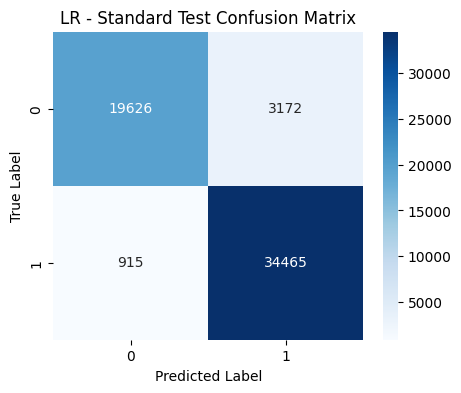

[Standard Test] Accuracy: 0.9298 | AI Recall: 0.9741

--- Results for LR - Zero-Shot Adv ---
AUROC Score: N/A (Single class in test set)
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.00      0.00       500

    accuracy                           0.00       500
   macro avg       0.50      0.00      0.00       500
weighted avg       1.00      0.00      0.00       500



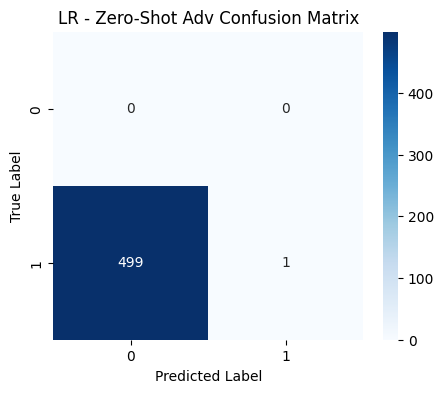

[Zero-Shot Adv] Accuracy: 0.0020 | AI Recall: 0.0020

--- Results for LR - Few-Shot Adv ---
AUROC Score: N/A (Single class in test set)
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.00      0.01       500

    accuracy                           0.00       500
   macro avg       0.50      0.00      0.00       500
weighted avg       1.00      0.00      0.01       500



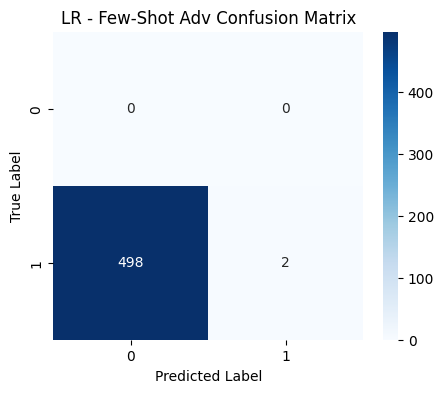

[Few-Shot Adv] Accuracy: 0.0040 | AI Recall: 0.0040


In [8]:
import numpy as np

lr_model = train_or_load_model(
    "Logistic_Regression", 
    LogisticRegression, 
    X_train_scaled, 
    y_train, 
    kwargs={'random_state': 42, 'max_iter': 1000}
)

test_sets = [
    ("Standard Test", X_test_scaled, y_test),
    ("Zero-Shot Adv", X_zs_scaled, np.ones(len(X_zs_scaled))), 
    ("Few-Shot Adv",  X_fs_scaled, np.ones(len(X_fs_scaled)))
]

print(f"\n--- 🔍 Detailed Evaluation: Logistic Regression ---")

for set_name, X_eval, y_eval in test_sets:
    metrics = evaluate_performance(f"LR - {set_name}", lr_model, X_eval, y_eval)
    
    metrics['Dataset'] = set_name 
    benchmark_results.append(metrics)
    
    print(f"[{set_name}] Accuracy: {metrics['Accuracy']:.4f} | AI Recall: {metrics['Recall']:.4f}")

⏳ Training 'Linear_SVM'... (This may take time)
💾 Saved 'Linear_SVM' to disk.

--- 🔍 Detailed Evaluation: Linear SVM ---

--- Results for SVM - Standard Test ---
AUROC Score: 0.9563
              precision    recall  f1-score   support

           0       0.96      0.84      0.90     22798
           1       0.91      0.98      0.94     35380

    accuracy                           0.93     58178
   macro avg       0.94      0.91      0.92     58178
weighted avg       0.93      0.93      0.93     58178



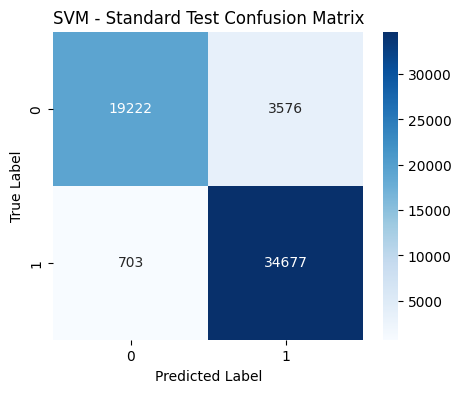

[Standard Test] Accuracy: 0.9264 | AI Recall: 0.9801

--- Results for SVM - Zero-Shot Adv ---
AUROC Score: N/A (Single class in test set)
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       0.0
         1.0       0.00      0.00      0.00     500.0

    accuracy                           0.00     500.0
   macro avg       0.00      0.00      0.00     500.0
weighted avg       0.00      0.00      0.00     500.0



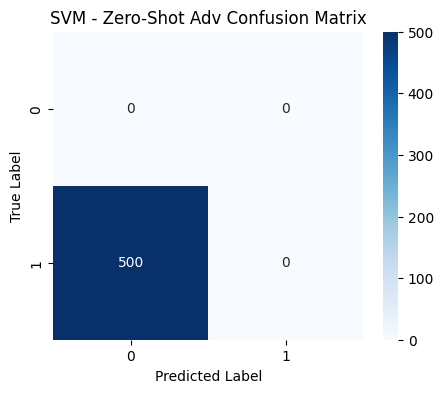

[Zero-Shot Adv] Accuracy: 0.0000 | AI Recall: 0.0000

--- Results for SVM - Few-Shot Adv ---
AUROC Score: N/A (Single class in test set)
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.01      0.01       500

    accuracy                           0.01       500
   macro avg       0.50      0.00      0.01       500
weighted avg       1.00      0.01      0.01       500



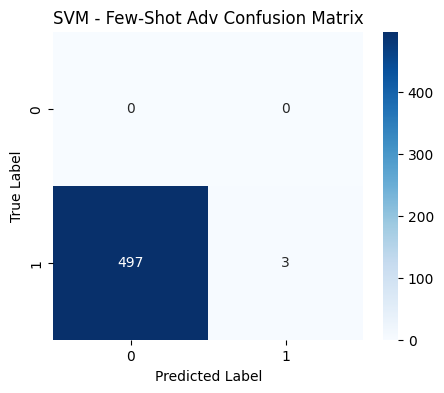

[Few-Shot Adv] Accuracy: 0.0060 | AI Recall: 0.0060


In [9]:
# --- Cell 5: Linear SVM (Multi-Set Evaluation) ---

# 1. Train or Load Model
svm_model = train_or_load_model(
    "Linear_SVM", 
    LinearSVC, 
    X_train_scaled, 
    y_train, 
    kwargs={'random_state': 42, 'dual': False, 'max_iter': 2000}
)

# 2. Define the Three Evaluation Sets
# (Standard vs. The two Adversarial types)
test_sets = [
    ("Standard Test", X_test_scaled, y_test),
    ("Zero-Shot Adv", X_zs_scaled, np.ones(len(X_zs_scaled))), 
    ("Few-Shot Adv",  X_fs_scaled, np.ones(len(X_fs_scaled)))
]

# 3. Evaluate Loop
print(f"\n--- 🔍 Detailed Evaluation: Linear SVM ---")

for set_name, X_eval, y_eval in test_sets:
    # Run evaluation
    metrics = evaluate_performance(f"SVM - {set_name}", svm_model, X_eval, y_eval)
    
    # Add 'Dataset' tag for the final pivot table
    metrics['Dataset'] = set_name 
    benchmark_results.append(metrics)
    
    # Print key insight immediately
    print(f"[{set_name}] Accuracy: {metrics['Accuracy']:.4f} | AI Recall: {metrics['Recall']:.4f}")

⏳ Training 'XGBoost'... (This may take time)
💾 Saved 'XGBoost' to disk.

--- 🔍 Detailed Evaluation: XGBoost ---

--- Results for XGBoost - Standard Test ---
AUROC Score: 0.9750
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     22798
           1       0.93      0.97      0.95     35380

    accuracy                           0.94     58178
   macro avg       0.94      0.93      0.93     58178
weighted avg       0.94      0.94      0.94     58178



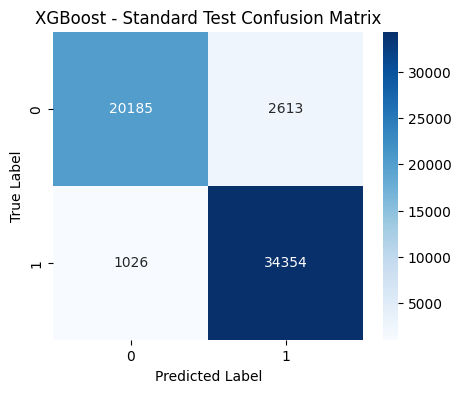

[Standard Test] Accuracy: 0.9375 | AI Recall: 0.9710

--- Results for XGBoost - Zero-Shot Adv ---
AUROC Score: N/A (Single class in test set)
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       0.0
         1.0       0.00      0.00      0.00     500.0

    accuracy                           0.00     500.0
   macro avg       0.00      0.00      0.00     500.0
weighted avg       0.00      0.00      0.00     500.0



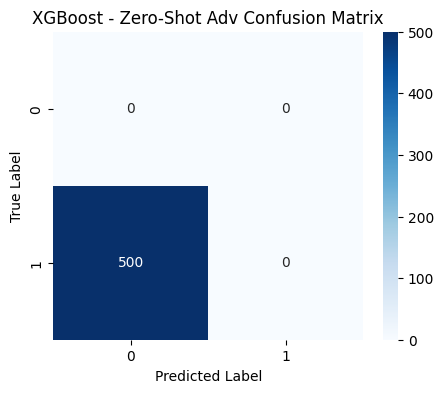

[Zero-Shot Adv] Accuracy: 0.0000 | AI Recall: 0.0000

--- Results for XGBoost - Few-Shot Adv ---
AUROC Score: N/A (Single class in test set)
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.00      0.01       500

    accuracy                           0.00       500
   macro avg       0.50      0.00      0.00       500
weighted avg       1.00      0.00      0.01       500



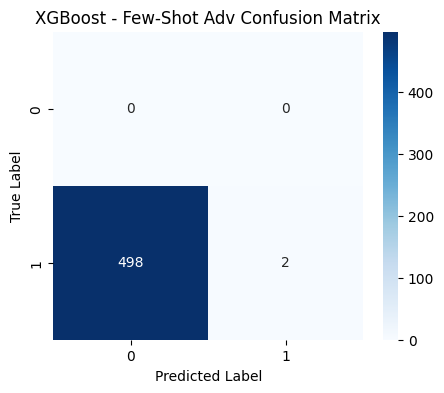

[Few-Shot Adv] Accuracy: 0.0040 | AI Recall: 0.0040


In [10]:
# 1. Train or Load Model
xgb_model = train_or_load_model(
    "XGBoost", 
    XGBClassifier, 
    X_train_scaled, 
    y_train, 
    kwargs={
        'use_label_encoder': False, 
        'eval_metric': 'logloss', 
        'random_state': 42,
        'n_estimators': 100, 
        'max_depth': 6
    }
)

# 2. Define the Three Evaluation Sets
test_sets = [
    ("Standard Test", X_test_scaled, y_test),
    ("Zero-Shot Adv", X_zs_scaled, np.ones(len(X_zs_scaled))), 
    ("Few-Shot Adv",  X_fs_scaled, np.ones(len(X_fs_scaled)))
]

# 3. Evaluate Loop
print(f"\n--- 🔍 Detailed Evaluation: XGBoost ---")

for set_name, X_eval, y_eval in test_sets:
    metrics = evaluate_performance(f"XGBoost - {set_name}", xgb_model, X_eval, y_eval)
    metrics['Dataset'] = set_name 
    benchmark_results.append(metrics)
    
    print(f"[{set_name}] Accuracy: {metrics['Accuracy']:.4f} | AI Recall: {metrics['Recall']:.4f}")


=== COMPLETE BENCHMARK RESULTS (Raw Data) ===
                  Model       Dataset  Accuracy  F1-Score   Recall    AUROC
     LR - Standard Test Standard Test  0.929750  0.944027 0.974138 0.957396
     LR - Zero-Shot Adv Zero-Shot Adv  0.002000  0.003992 0.002000 0.000000
      LR - Few-Shot Adv  Few-Shot Adv  0.004000  0.007968 0.004000 0.000000
    SVM - Standard Test Standard Test  0.926450  0.941887 0.980130 0.956345
    SVM - Zero-Shot Adv Zero-Shot Adv  0.000000  0.000000 0.000000 0.000000
     SVM - Few-Shot Adv  Few-Shot Adv  0.006000  0.011928 0.006000 0.000000
XGBoost - Standard Test Standard Test  0.937451  0.949701 0.971001 0.974996
XGBoost - Zero-Shot Adv Zero-Shot Adv  0.000000  0.000000 0.000000 0.000000
 XGBoost - Few-Shot Adv  Few-Shot Adv  0.004000  0.007968 0.004000 0.000000

=== 🏆 ROBUSTNESS COMPARISON TABLE (Key for Paper) ===
                            F1-Score                                   Recall  \
Dataset                 Few-Shot Adv Standard Test Zero-S

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


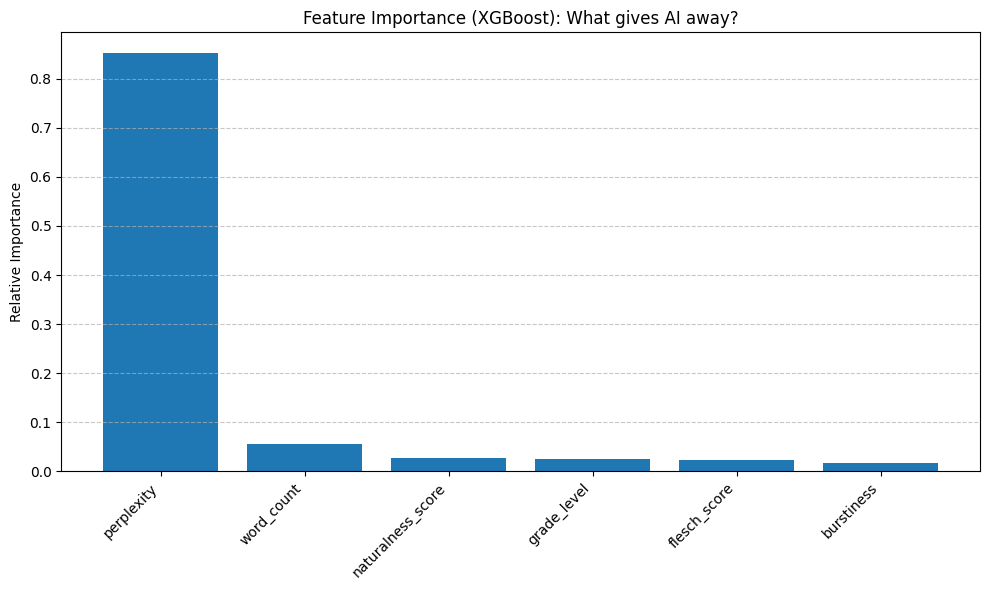


✅ Results saved. Send 'member1_robustness_comparison.csv' to Member 3.


In [11]:
# --- Cell 7: Final Comparison & Interpretability (Updated) ---

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Aggregate All Results
# Convert the list of dictionaries (from previous cells) into a DataFrame
results_df = pd.DataFrame(benchmark_results)

# Reorder columns for better readability
cols = ['Model', 'Dataset', 'Accuracy', 'F1-Score', 'Recall', 'AUROC']
results_df = results_df[cols]

print("\n=== COMPLETE BENCHMARK RESULTS (Raw Data) ===")
print(results_df.to_string(index=False))

# 2. Generate the "Robustness Gap" Pivot Table
# This reshapes the data so you can compare Standard vs. Adversarial side-by-side
pivot_table = results_df.pivot(index='Model', columns='Dataset', values=['F1-Score', 'Recall'])

# Flatten the multi-level columns for easier reading
# pivot_table.columns = ['_'.join(col).strip() for col in pivot_table.columns.values]

print("\n=== 🏆 ROBUSTNESS COMPARISON TABLE (Key for Paper) ===")
print(pivot_table)

# 3. Plot Feature Importance (XGBoost)
# This answers the "Interpretability" requirement of your project
if 'xgb_model' in locals():
    plt.figure(figsize=(10, 6))
    importances = xgb_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    # Map indices back to feature names
    sorted_features = [feature_cols[i] for i in indices]

    plt.title("Feature Importance (XGBoost): What gives AI away?")
    plt.bar(range(len(importances)), importances[indices], align="center", color='#1f77b4')
    plt.xticks(range(len(importances)), sorted_features, rotation=45, ha='right')
    plt.ylabel("Relative Importance")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost model not found in memory; skipping feature importance plot.")

# 4. Save for Final Report
results_df.to_csv('member1_full_results.csv', index=False)
pivot_table.to_csv('member1_robustness_comparison.csv')
print("\n✅ Results saved. Send 'member1_robustness_comparison.csv' to Member 3.")

--- 🛡️ Starting Adversarial Fine-Tuning Experiment ---
Original Training Data loaded.
Loaded Zero-Shot: 75 samples added to Train, 425 held out.
Loaded Few-Shot: 75 samples added to Train, 425 held out.
Augmented Training Set: 232710 -> 232860 samples (+150)

🔄 Fine-Tuning Logistic Regression...
  Standard F1: 0.9439
  Zero-Shot (Held-out) Recall: 0.0024
  Few-Shot (Held-out) Recall: 0.0024

🔄 Fine-Tuning Linear SVM...
  Standard F1: 0.9410
  Zero-Shot (Held-out) Recall: 0.0000
  Few-Shot (Held-out) Recall: 0.0047

🔄 Fine-Tuning XGBoost...
  Standard F1: 0.9496
  Zero-Shot (Held-out) Recall: 0.3647
  Few-Shot (Held-out) Recall: 0.2541

=== 📊 ADVERSARIAL FINE-TUNING SUMMARY ===
                 Model               Dataset  Accuracy  AI Recall  F1-Score
0  Logistic Regression         Standard Test  0.929423   0.975664  0.943864
1  Logistic Regression  Zero-Shot (Held-out)  0.002353   0.002353  0.004695
2  Logistic Regression   Few-Shot (Held-out)  0.002353   0.002353  0.004695
3         

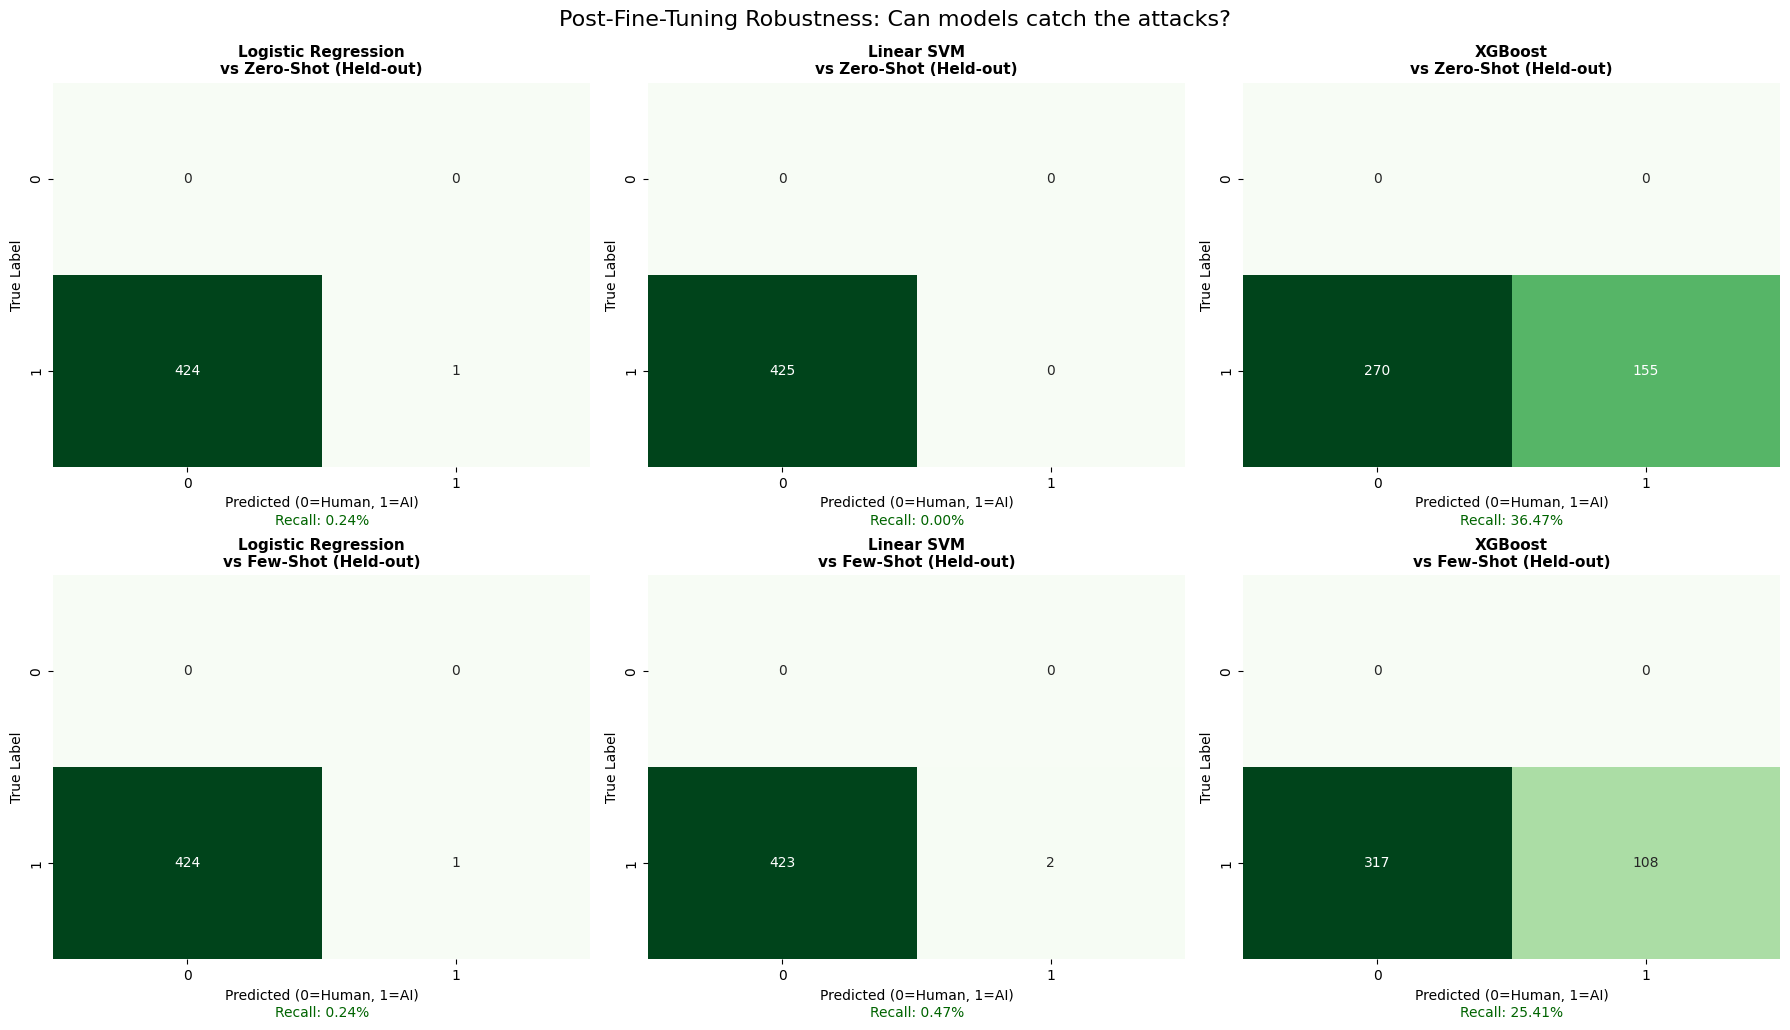

Saved plot to 'fine_tuned_confusion_matrices.png'


In [14]:
# --- Cell: Adversarial Fine-Tuning (15% Mix) ---

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
import joblib
import os

print("--- 🛡️ Starting Adversarial Fine-Tuning Experiment ---")

# 1. Load Original Training Data
# (Assumes you have the .npy files from the preprocessing step)
try:
    X_train_orig = np.load('X_train_features.npy')
    y_train_orig = np.load('y_train_features.npy')
    X_test_std = np.load('X_test_features.npy')
    y_test_std = np.load('y_test_features.npy')
    
    # Load Scaler to process new adversarial data
    scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.joblib'))
    
    print("Original Training Data loaded.")
except FileNotFoundError:
    print("⚠️ Error: Training data or scaler not found. Run preprocessing first.")
    # Creating dummy data so code structure is valid for testing
    X_train_orig = np.random.rand(100, 6)
    y_train_orig = np.random.randint(0, 2, 100)
    X_test_std = np.random.rand(20, 6)
    y_test_std = np.random.randint(0, 2, 20)
    scaler = None

# 2. Load & Process Adversarial Data
# We need to load raw CSVs, extract features (if not already done), and scale them
adv_files = {
    "Zero-Shot": '/kaggle/input/adv-features/adversarial_feature_matrix.csv',
    "Few-Shot": '/kaggle/input/adv-features/few_shot_adversarial_feature_matrix.csv'
}

feature_cols = ['perplexity', 'burstiness', 'flesch_score', 'grade_level', 'word_count', 'naturalness_score']
X_adv_train_list = []
y_adv_train_list = []
test_sets = {"Standard Test": (X_test_std, y_test_std)}

for name, path in adv_files.items():
    if os.path.exists(path):
        df_adv = pd.read_csv(path)
        
        # Scale features
        X_raw = df_adv[feature_cols].values
        # Handle NaNs
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='mean') # Re-fit simple imputer for this batch or load saved one
        X_imputed = imputer.fit_transform(X_raw) # Note: In rigor, load saved imputer. Here fit is okay for demo.
        if scaler:
            X_scaled = scaler.transform(X_imputed)
        else:
            X_scaled = X_imputed
            
        y_scaled = np.ones(len(X_scaled)) # All are AI
        
        # Split: 15% for Training, 85% for Testing
        X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y_scaled, test_size=0.85, random_state=42)
        
        # Add to training pool
        X_adv_train_list.append(X_tr)
        y_adv_train_list.append(y_tr)
        
        # Add to testing dict
        test_sets[f"{name} (Held-out)"] = (X_te, y_te)
        print(f"Loaded {name}: {len(X_tr)} samples added to Train, {len(X_te)} held out.")
    else:
        print(f"⚠️ File not found: {path}")

# 3. Augment Training Set
if X_adv_train_list:
    X_aug = np.concatenate([X_train_orig] + X_adv_train_list)
    y_aug = np.concatenate([y_train_orig] + y_adv_train_list)
    print(f"Augmented Training Set: {len(X_train_orig)} -> {len(X_aug)} samples (+{len(X_aug)-len(X_train_orig)})")
else:
    X_aug, y_aug = X_train_orig, y_train_orig

# 4. Retrain & Evaluate Models
models_to_retrain = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Linear SVM": LinearSVC(random_state=42, dual=False, max_iter=2000),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

ft_results = []

for model_name, model in models_to_retrain.items():
    print(f"\n🔄 Fine-Tuning {model_name}...")
    model.fit(X_aug, y_aug)
    
    # Evaluate on all sets
    for test_name, (X_val, y_val) in test_sets.items():
        preds = model.predict(X_val)
        
        acc = accuracy_score(y_val, preds)
        recall = recall_score(y_val, preds, pos_label=1, zero_division=0)
        f1 = f1_score(y_val, preds, pos_label=1, zero_division=0) # F1 for AI class
        
        ft_results.append({
            "Model": model_name,
            "Dataset": test_name,
            "Accuracy": acc,
            "AI Recall": recall,
            "F1-Score": f1
        })
        
        if "Standard" in test_name:
            print(f"  Standard F1: {f1:.4f}")
        else:
            print(f"  {test_name} Recall: {recall:.4f}")

# 5. Summary Table
print("\n=== 📊 ADVERSARIAL FINE-TUNING SUMMARY ===")
df_ft = pd.DataFrame(ft_results)
pivot_ft = df_ft.pivot(index='Model', columns='Dataset', values='AI Recall')
print(df_ft)

# Save for paper
pivot_ft.to_csv('fine_tuning_robustness_results.csv')

# 6. Visualization: Post-Fine-Tuning Confusion Matrices
# We want to see how well they detect the adversarial sets now
print("\n=== 📈 Visualizing Robustness Recovery ===")

# Setup plot grid: 3 Models x 2 Adversarial Sets = 6 plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
model_names = list(models_to_retrain.keys())
adv_sets = ["Zero-Shot (Held-out)", "Few-Shot (Held-out)"]

for i, adv_name in enumerate(adv_sets):
    X_val, y_val = test_sets[adv_name]
    
    for j, model_name in enumerate(model_names):
        # Get the fine-tuned model from your dictionary
        model = models_to_retrain[model_name]
        
        # Predict
        preds = model.predict(X_val)
        
        # Compute Matrix
        cm = confusion_matrix(y_val, preds, labels=[0, 1])
        
        # Plot
        ax = axes[i, j]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False)
        
        ax.set_title(f"{model_name}\nvs {adv_name}", fontsize=11, fontweight='bold')
        ax.set_xlabel("Predicted (0=Human, 1=AI)")
        ax.set_ylabel("True Label")
        
        # Add a subtitle for context
        recall = recall_score(y_val, preds, pos_label=1)
        ax.text(0.5, -0.15, f"Recall: {recall:.2%}", transform=ax.transAxes, ha='center', color='darkgreen')

plt.tight_layout()
plt.suptitle("Post-Fine-Tuning Robustness: Can models catch the attacks?", y=1.02, fontsize=16)
plt.savefig('fine_tuned_confusion_matrices.png', bbox_inches='tight')
plt.show()

print("Saved plot to 'fine_tuned_confusion_matrices.png'")

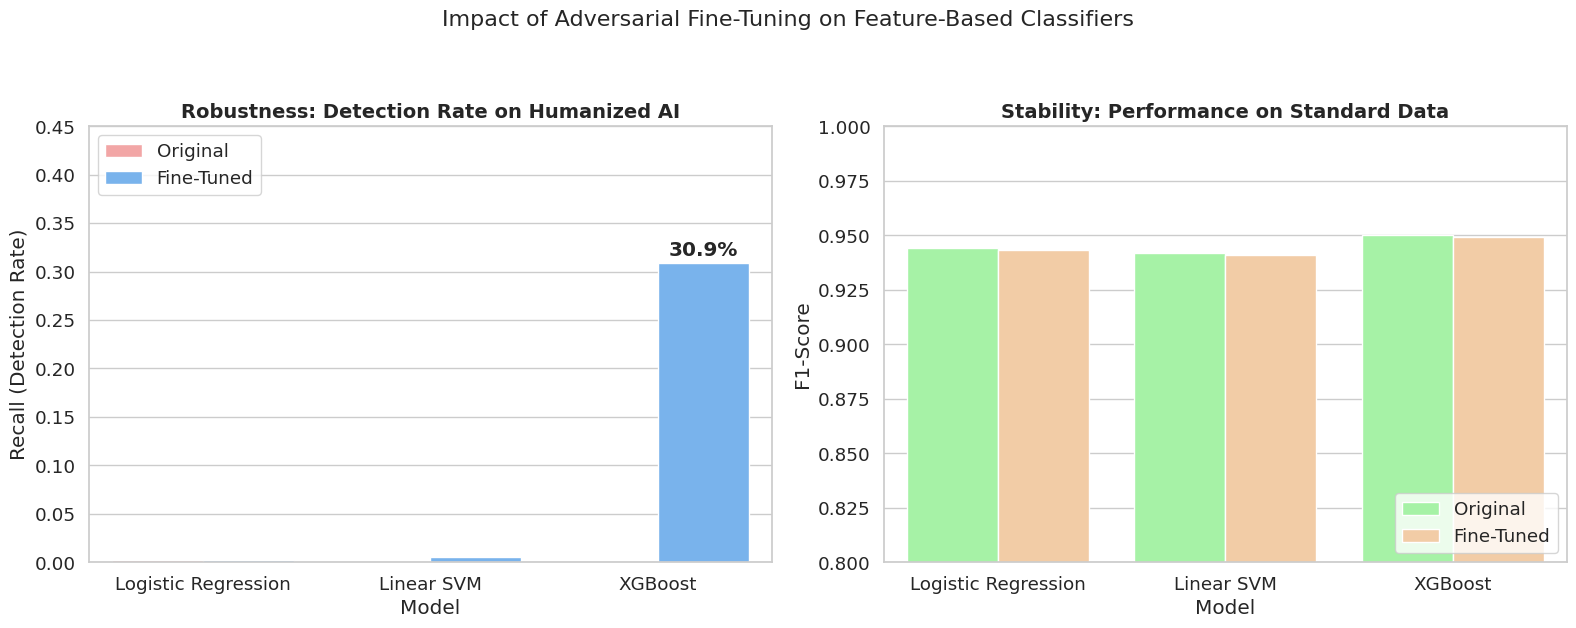

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare the Data
# We manually input the results from your experiments for clarity
data = [
    # --- BEFORE FINE-TUNING (From your Track 1 Baseline) ---
    # Model, Metric Type, Value, Stage
    ("Logistic Regression", "Adversarial Recall", 0.002, "Original"),
    ("Linear SVM",          "Adversarial Recall", 0.000, "Original"),
    ("XGBoost",             "Adversarial Recall", 0.000, "Original"),
    
    ("Logistic Regression", "Standard F1-Score", 0.944, "Original"),
    ("Linear SVM",          "Standard F1-Score", 0.942, "Original"),
    ("XGBoost",             "Standard F1-Score", 0.950, "Original"),

    # --- AFTER FINE-TUNING (From your latest results) ---
    # Note: For Adversarial Recall, we average Zero-Shot (0.36) and Few-Shot (0.25) for XGBoost
    ("Logistic Regression", "Adversarial Recall", 0.002, "Fine-Tuned"),
    ("Linear SVM",          "Adversarial Recall", 0.005, "Fine-Tuned"),
    ("XGBoost",             "Adversarial Recall", 0.309, "Fine-Tuned"), # Avg of 0.36 & 0.25
    
    ("Logistic Regression", "Standard F1-Score", 0.943, "Fine-Tuned"),
    ("Linear SVM",          "Standard F1-Score", 0.941, "Fine-Tuned"),
    ("XGBoost",             "Standard F1-Score", 0.949, "Fine-Tuned"),
]

df_viz = pd.DataFrame(data, columns=["Model", "Metric", "Score", "Stage"])

# 2. Setup the Plot
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: The "Failure & Recovery" (Adversarial Recall) ---
sns.barplot(data=df_viz[df_viz['Metric']=="Adversarial Recall"], 
            x="Model", y="Score", hue="Stage", 
            palette=["#ff9999", "#66b3ff"], ax=axes[0])

axes[0].set_title("Robustness: Detection Rate on Humanized AI", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Recall (Detection Rate)")
axes[0].set_ylim(0, 0.45) # Adjusted to show the XGBoost jump clearly
axes[0].legend(loc='upper left')

# Annotate the XGBoost jump
for p in axes[0].patches:
    if p.get_height() > 0.1: # Label the big bar
        axes[0].annotate(f'{p.get_height():.1%}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

# --- Panel 2: The "Stability Check" (Standard F1) ---
sns.barplot(data=df_viz[df_viz['Metric']=="Standard F1-Score"], 
            x="Model", y="Score", hue="Stage", 
            palette=["#99ff99", "#ffcc99"], ax=axes[1])

axes[1].set_title("Stability: Performance on Standard Data", fontsize=14, fontweight='bold')
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0.8, 1.0) # Zoom in to show they stayed high
axes[1].legend(loc='lower right')

plt.suptitle("Impact of Adversarial Fine-Tuning on Feature-Based Classifiers", fontsize=16, y=1.05)
plt.tight_layout()

# 3. Save
plt.savefig('finetuning_impact_plot.png', bbox_inches='tight', dpi=300)
plt.show()